# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

# Sample EDA (Exploratory Data Analysis) Project:
Nothing but a data analysis attempt (actually my first ever). <br>
Dataset used: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset/data - Steam store data<br>
Luckily for me, there was a missing comma in the header row inside the .csv file, certified classic.
### Goals:
* Find differences between platforms (which one dominates, tho one could assume it's going to be windows)
* Explore correlation between price and review scores
* Compare numbers of releases and average scores between years
* Study correlation between estimated owners and average playtime
* Check whether release date influences price (if newer releases could be considered more expensive)
* Achievements vs Playtime (Engagement Analysis) - do achievements make players want to play more?

In [130]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print(pd.__version__)
print(np.__version__)

2.2.3
2.3.1


# Data Cleanup
There was a missing comma in the header row inside the .csv file which was put back in place. <br>
Next we need to choose data that we want to process, especially because of most columns having up to 80% NULL values

# Selection of relevant data

In [131]:
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Seaborn: {sns.__version__}")

usecols = ["AppID", "Name", "Release date", "Estimated owners", "Price", "Supported languages", "Windows", "Mac", "Linux", "Metacritic score", "Achievements", "Average playtime forever", "Categories", "Genres"]
df = pd.read_csv("games.csv", usecols=usecols, sep=",", header=0)


print(df.info())

Pandas: 2.2.3
NumPy: 2.3.1
Seaborn: 0.13.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AppID                     122611 non-null  int64  
 1   Name                      122610 non-null  object 
 2   Release date              122611 non-null  object 
 3   Estimated owners          122611 non-null  object 
 4   Price                     122611 non-null  float64
 5   Supported languages       122611 non-null  object 
 6   Windows                   122611 non-null  bool   
 7   Mac                       122611 non-null  bool   
 8   Linux                     122611 non-null  bool   
 9   Metacritic score          122611 non-null  int64  
 10  Achievements              122611 non-null  int64  
 11  Average playtime forever  122611 non-null  int64  
 12  Categories                113658 non-null  object 
 13  G

In [132]:
df["Release date"]=pd.to_datetime(df["Release date"], errors="coerce")
df=df.dropna(subset=['Name'])
df=df.dropna(subset=['Release date'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 122610 entries, 0 to 122610
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   AppID                     122610 non-null  int64         
 1   Name                      122610 non-null  object        
 2   Release date              122610 non-null  datetime64[ns]
 3   Estimated owners          122610 non-null  object        
 4   Price                     122610 non-null  float64       
 5   Supported languages       122610 non-null  object        
 6   Windows                   122610 non-null  bool          
 7   Mac                       122610 non-null  bool          
 8   Linux                     122610 non-null  bool          
 9   Metacritic score          122610 non-null  int64         
 10  Achievements              122610 non-null  int64         
 11  Average playtime forever  122610 non-null  int64         
 12  Categor

# 1) Comparing NO. of releases for each platform:

Windows    122566
Mac         21292
Linux       15706
dtype: int64


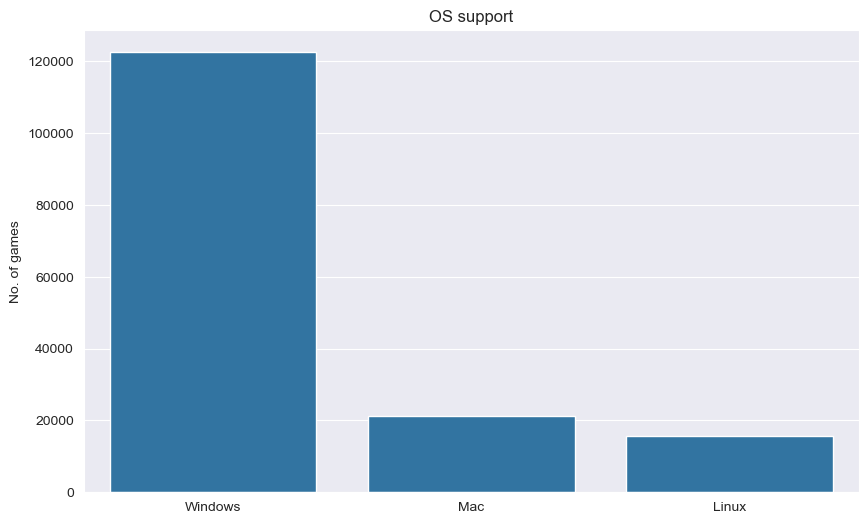

In [133]:
platforms = df[['Windows', 'Mac', 'Linux']].sum()
print(platforms)

plt.figure(figsize=(10, 6))
sns.barplot(x=platforms.index, y=platforms.values)
plt.title('OS support')
plt.xlabel('')
plt.ylabel('No. of games')
plt.show()

It was quite predictable that Windows was going to dominate the field although it's worth mentioning that not ALL of the games are supported on it

# 2) Exploring the relationship between price and metacritic scores
##### !A score of 0 is considered as NotGiven!
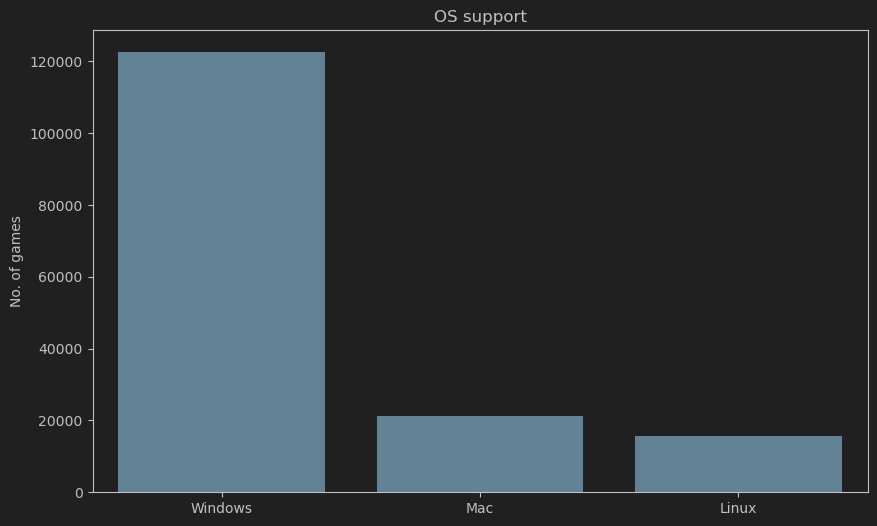

Let's begin by creating a dataframe filled with records which were given a score different from 0:

No. records:  4022


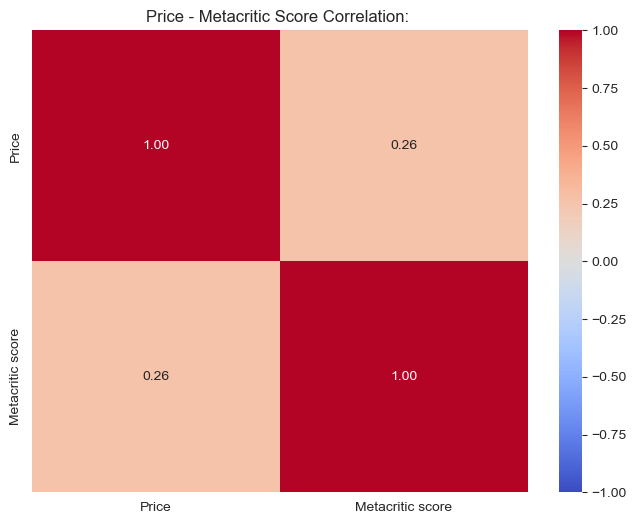

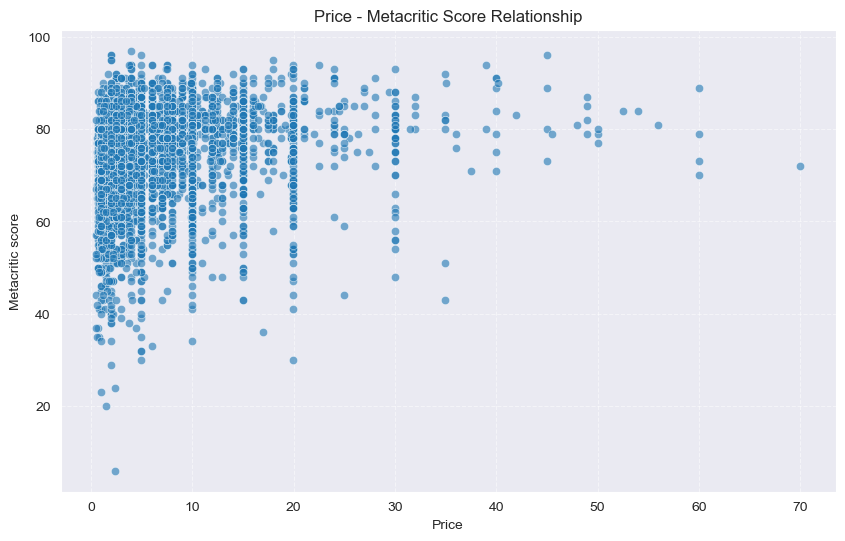

In [142]:
df_price_metacritic = df[(df['Price'] > 0) & (df['Metacritic score'] > 0)].copy()

print("No. records: ", len(df_price_metacritic))

corr_matrix = df_price_metacritic[['Price', 'Metacritic score']].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Price - Metacritic Score Correlation: ')


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_price_metacritic, x='Price', y='Metacritic score', alpha=0.6)
plt.title('Price - Metacritic Score Relationship')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Only a relatively small amount of records had a Meta score > 0 (4k out of 120k). One could say that it makes most of the games available on steam rather "niche". "Niche" enough to not grab gaming media's interest <br>
One could find this quite intuitive due to metacritic being known for reviewing games of mostly great popularity.
Our correlation matrix calculated for this sample shows signs that there is no meaningful correlation between these two.
<br> We can dive a bit deeper and check how price differs between games with __really high__ review scores (>80):

No. records:  1076


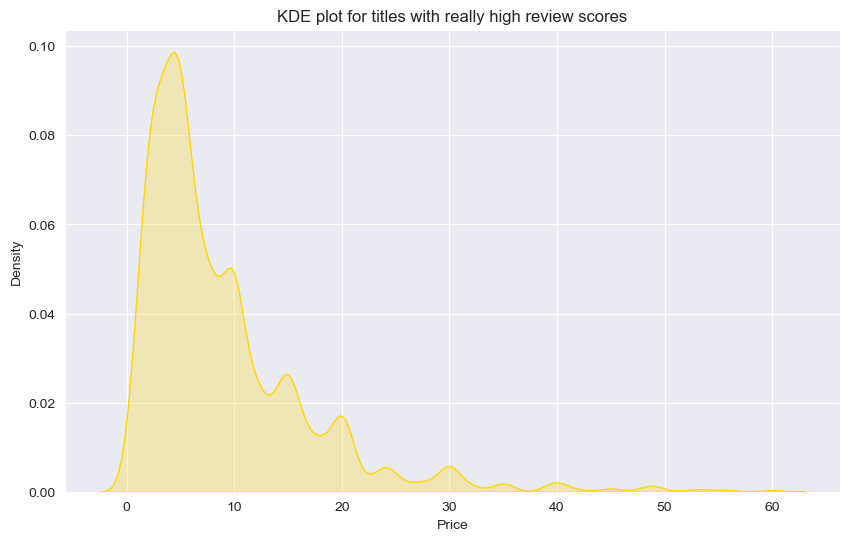

Mode:  0    4.99
Name: Price, dtype: float64
Median:  5.99


In [143]:
df_price_metacritic_high=df_price_metacritic[df_price_metacritic['Metacritic score']>80].copy()
print("No. records: ", len(df_price_metacritic_high))

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_price_metacritic_high, x='Price', fill=True, bw_adjust=0.5, color='gold')
plt.title('KDE plot for titles with really high review scores')
plt.show()
print("Mode: ", df_price_metacritic_high['Price'].mode())
print("Median: ", df_price_metacritic_high['Price'].median())

Based on available data we can say that the "average" very positively reviewed game costs up to 10 USD (Seems like indie games are winning critics' hearts over AAA games). <br>
It is worth mentioning that there is visible skewness to the right. <br>
What's also interesting is that we can see spikes at a few price points which might be connected to the fact that most devs publish games at popular prices we usually see on the main store page such as [USD] 4.99; 7.99; 9.99; 14.99; 17.99; 19.99 etc. I believe these prices correspond with results from many psychological studies about what buyers think (I believe it also connects with the prices we see in physical stores)

Now let's take a look from a different angle: Do expensive (>39USD - arbitrary cutoff) games tend to have higher scores?

No. Premium with high rating:  16
Premium with rating > 0:  30
Premium Overall:  885

No. Budget with high rating:  1060
Budget with rating > 0:  4226


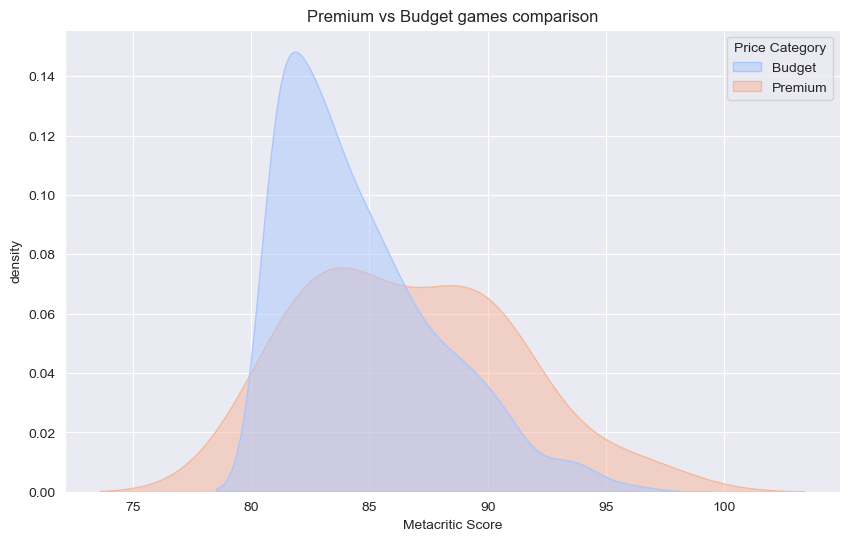

In [144]:
cutoff=39
df_price_metacritic_high['Price Category'] = df_price_metacritic_high['Price'].apply(
    lambda x: 'Premium' if x > cutoff else 'Budget'
)
print('No. Premium with high rating: ', len(df_price_metacritic_high[df_price_metacritic_high['Price Category'] == 'Premium']))
print('Premium with rating > 0: ', len(df[(df['Price'] > cutoff) & (df['Metacritic score'] > 0)]))
print('Premium Overall: ', len(df[df['Price'] > cutoff]), end='\n\n')
print('No. Budget with high rating: ', len(df_price_metacritic_high[df_price_metacritic_high['Price Category'] == 'Budget']))
print('Budget with rating > 0: ', len(df[(df['Price'] <= cutoff) & (df['Metacritic score'] > 0)]))

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_price_metacritic_high, x='Metacritic score', hue='Price Category',
            fill=True, common_norm=False, palette='coolwarm', alpha=0.5)

plt.title('Premium vs Budget games comparison')
plt.xlabel('Metacritic Score')
plt.ylabel('density')
plt.show()

It's important to note that these categories are very imbalanced in terms of size (16 Premium :: 1060 budget). It seems that only 16 out of 885 (whilst only 30 of 885 received any scores) premium games were rated as high which visibly distorts the kde plot and makes it prone to changes. One may conclude that Premium games have higher expectations due to their premium price compared to budget productions. <br>
One could draw a conclusion that a higher budget meaning a better (or one in general) marketing campaign does not directly result in the game receiving better scores.<br>
However, let's see how scores distribute for all premium games if we don't take into account only the highly scored titles.

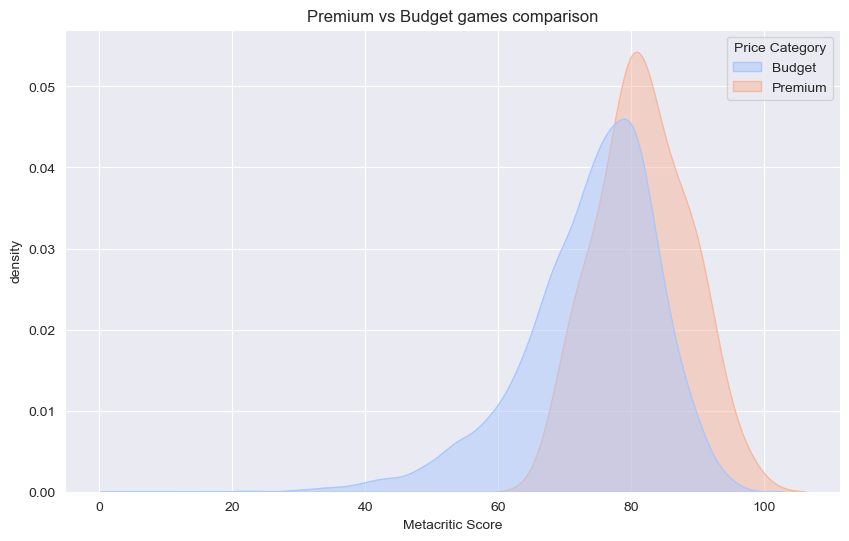

In [145]:
df_price_metacritic['Price Category'] = df_price_metacritic['Price'].apply(
    lambda x: 'Premium' if x > cutoff else 'Budget'
)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_price_metacritic, x='Metacritic score', hue='Price Category',
            fill=True, common_norm=False, palette='coolwarm', alpha=0.5)

plt.title('Premium vs Budget games comparison')
plt.xlabel('Metacritic Score')
plt.ylabel('density')
plt.show()

Now the "premium" price range kde plot for scores seems a bit smoother, although we are still working on a relatively small sample size. We can see the difference in variance between the two plots with visible skewness to the left in the budget category. <br>
To close off this chapter let's also look if scores can tell us something about the number of estimated owners. First we'll need to parse our current data in the estimated owners collumn from a string to a number. Let's check what the values look like.

In [146]:
print(df_price_metacritic['Estimated owners'].value_counts())

Estimated owners
200000 - 500000         761
0 - 20000               580
100000 - 200000         564
50000 - 100000          529
20000 - 50000           502
500000 - 1000000        420
1000000 - 2000000       329
2000000 - 5000000       225
5000000 - 10000000       61
10000000 - 20000000      23
0 - 0                    14
20000000 - 50000000      13
50000000 - 100000000      1
Name: count, dtype: int64


Now, let's add a column with values set to the mean of their corresponding interval:

In [147]:
split_data = df_price_metacritic['Estimated owners'].str.split(' - ', expand=True).astype(float)
df_price_metacritic['Owners midpoint'] = split_data.mean(axis=1)

Let's visualise the relationship between score and estimated owners as well as calculate correlation between the two:

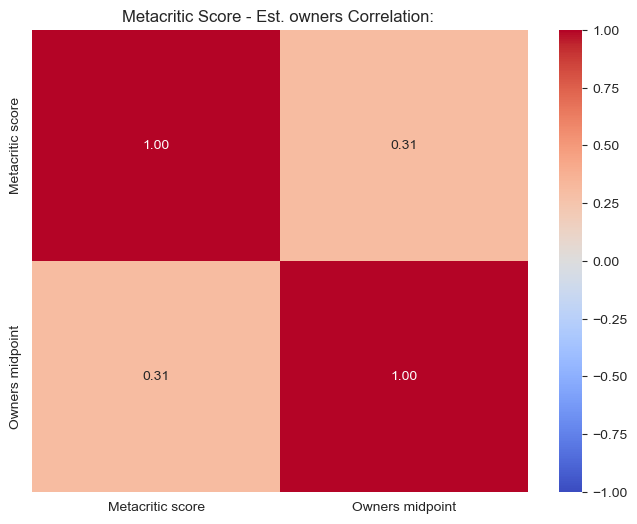

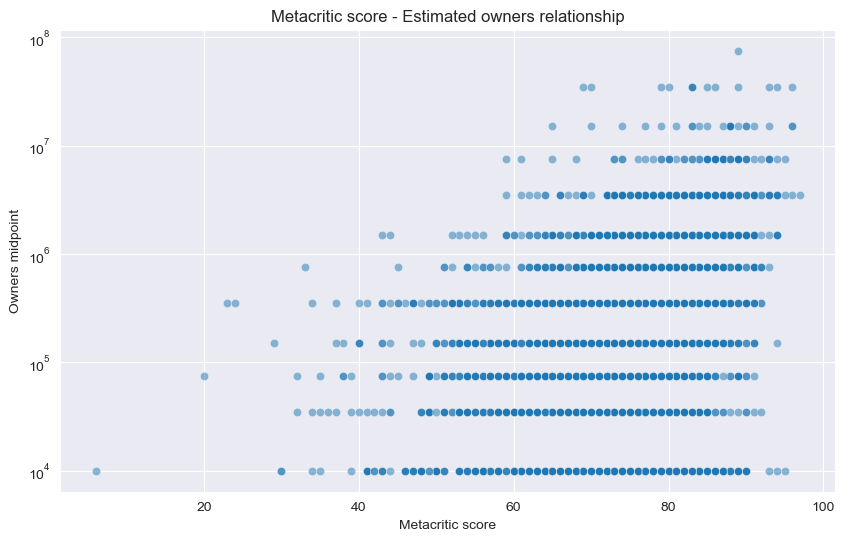

In [148]:
plt.figure(figsize=(8, 6))
corr_matrix = df_price_metacritic[['Metacritic score', 'Owners midpoint']].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Metacritic Score - Est. owners Correlation: ')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_price_metacritic, x='Metacritic score', y='Owners midpoint', alpha=0.5)
plt.yscale('log')
plt.title('Metacritic score - Estimated owners relationship')

plt.show()


We can see a subtle tendency for games with a lot of owners (midpoint above 1 mil) to fall onto the right side of the plot. It's important to note that a high score does **NOT** guarantee a lot of owners (we can see a lot of games with high scores but less owners) but it seems that high scores could mean a higher probability for the game to acquire a lot of players.

### To summarize:
* Only a small percentage of games (around 3%) received a Metacritic score, suggesting that a large amount of games published on steam don't get the privilege of attracting gaming media's attention.
* Games with really high review scores mostly cost less than 10 USD which implies that indie games tend to win over their critics hearts (Maybe because of expensive games bringing more expectations?).
* Price Density estimation plot shows tendencies in game pricing (e.g 7.99 USD, 14.99 USD), which shows signs of devs applying sales psychology.
* Data lacks correlation between price and review scores: A higher prices does not directly result in higher scores ("Premium" group >39 USD).
* Metacritic scores vs Est. owners: Scores tend to play a role in allowing a game to reach a huge player count although they do not strictly guarantee the game being a unicorn. There are lots of games with a relatively small playerbase rated really generously.


# 3) Comparing the numbers of releases and average scores over the years

We need to remember about the fact that a score of 0 means no score at all not an actual score of 0. Thanks to how the mean in pandas automatically ignores NaN values we can simply replace our 0s with NaNs.

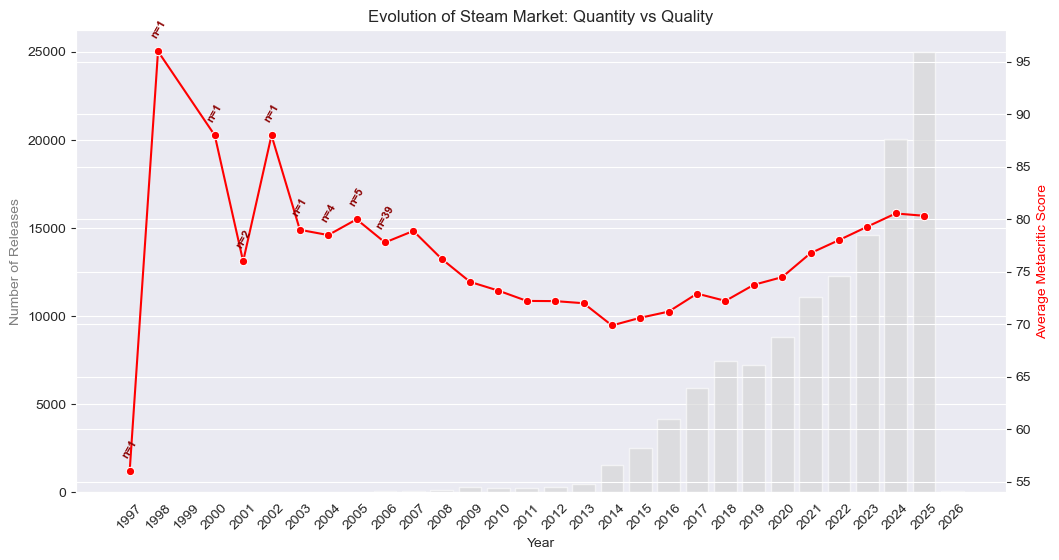

In [149]:
yearly_stats=df.copy()
yearly_stats['Year']=yearly_stats['Release date'].dt.year
yearly_stats['Metacritic score']=yearly_stats['Metacritic score'].replace(to_replace=0, value=np.nan)

# rok=2026
#
# print(yearly_stats[yearly_stats['Year']==rok].count())
# print(yearly_stats[yearly_stats['Year']==rok].head())

yearly_stats = yearly_stats.groupby('Year').agg({
    'AppID': 'count',
    'Metacritic score': ['mean', 'count']
})

yearly_stats.columns = ['Game Count', 'Avg Score', 'Rated Count']

fig, ax1 = plt.subplots(figsize=(12,6))
plt.xticks(rotation=45)

sns.barplot(x=yearly_stats.index, y=yearly_stats['Game Count'], ax=ax1, color='lightgray', alpha=0.6)
ax1.set_ylabel('Number of Releases', color='gray')

ax2 = ax1.twinx()
sns.lineplot(x=range(len(yearly_stats)), y=yearly_stats['Avg Score'], ax=ax2, color='red', marker='o')
ax2.set_ylabel('Average Metacritic Score', color='red')

#annotating means with small sample sizes
for i, (year, row) in enumerate(yearly_stats.iterrows()):
    n_rated = int(row['Rated Count'])
    if n_rated <= 50:
        ax2.text(i, row['Avg Score'] + 1.1, f"n={n_rated}",
                 color='darkred', ha='center', va='bottom',
                 fontsize=8, rotation=60, fontweight='bold')


plt.title('Evolution of Steam Market: Quantity vs Quality')


plt.show()



We can see an exponential-like growth in the number of releases after 2014 - possibly due to steam introducing greenlight (which was later replaced with steam direct around 2018) - a mechanism/platform for devs to showcase their games so the community could vote whether the game should come to steam.

It is very important to note that games released before 2003 were added to steam only after the platform was created. I've also added annotations for Metacritic Score means calculated for less than 50 titles (To emphasize the stability of the scores or rather lack of it)
1998 is also a quite important year because that's when valve released half-life, the game that changed everything for them and brought the capital necessary to create more games and ultimately - steam.

The plot also tells us that not only did the amount of games receiving scores increase but also their mean scores have been increasing since 2014. This might connect with the release of greenlight - although it was flawed I believe it had somewhat of a contribution - because games receiving community votes before coming to steam would technically get their first form of quality control before receiving actual critic reviews.

# 4) Studying correlation between estimated owners and average playtime

# 5) Check whether release date influences price (if newer releases could be considered more expensive)

# 6) Achievements vs Playtime (Engagement Analysis) - do achievements make players want to play more?


Personally I'm an achievement hunter so I'm not sure whether that's a good or a bad thing. What I want to find out is whether completionism is a niche thing or do most players spend more time playing games which showcase their progress in the form of achievements.